# Feature Engineering Analysis for PredSeeker

This notebook demonstrates the feature engineering techniques used in the PredSeeker project to predict developer employment status. We'll explore:

1. **Skill Family Scoring System**
2. **Demographics Analysis** 
3. **Technical Skills Analysis**
4. **Correlation Analysis**
5. **Employment Prediction Features**
6. **Technology-Specific Employment Patterns**

Our feature engineering transforms raw Stack Overflow survey data into meaningful predictive features using innovative skill family frameworks.

In [14]:
# Import Required Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 10]

# Define SKILL_FAMILIES used in preprocessing
SKILL_FAMILIES = {
    'Programming': [
        'Python', 'Java', 'JavaScript', 'C++', 'C#', 'C', 'PHP', 'Ruby', 
        'Go', 'Rust', 'Swift', 'Kotlin', 'Scala', 'R', 'Matlab', 'Perl',
        'TypeScript', 'Dart', 'F#', 'Assembly', 'Delphi', 'VBA'
    ],
    'Web': [
        'HTML/CSS', 'React.js', 'Angular', 'Vue.js', 'Node.js', 'Express',
        'jQuery', 'Angular.js', 'Svelte', 'Django', 'Flask', 'Laravel',
        'Ruby on Rails', 'ASP.NET', 'ASP.NET Core', 'Spring', 'FastAPI'
    ],
    'Database': [
        'MySQL', 'PostgreSQL', 'MongoDB', 'SQLite', 'Redis', 'Oracle',
        'Microsoft SQL Server', 'MariaDB', 'DynamoDB', 'Elasticsearch',
        'Couchbase', 'Firebase', 'SQL'
    ],
    'CloudDevOps': [
        'AWS', 'Microsoft Azure', 'Google Cloud Platform', 'Docker', 
        'Kubernetes', 'Git', 'Terraform', 'Ansible', 'Heroku',
        'DigitalOcean', 'Bash/Shell', 'PowerShell'
    ]
}

print("✅ Libraries imported successfully!")
print(f"🔧 Defined {len(SKILL_FAMILIES)} skill families with {sum(len(techs) for techs in SKILL_FAMILIES.values())} total technologies")

✅ Libraries imported successfully!
🔧 Defined 4 skill families with 64 total technologies


In [15]:
# Load the preprocessed data
try:
    df = pd.read_csv('../data/processed/preprocessed_data_clean.csv')
    print("✅ Data loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
    print("\n📋 Dataset Info:")
    print(f"   • Total developers: {len(df):,}")
    if 'Employed' in df.columns:
        print(f"   • Employed developers: {df['Employed'].sum():,} ({df['Employed'].mean()*100:.1f}%)")
        print(f"   • Unemployed developers: {(~df['Employed']).sum():,} ({(1-df['Employed'].mean())*100:.1f}%)")
    
    print(f"\n🔍 Available columns ({len(df.columns)}):")
    for i, col in enumerate(df.columns):
        if i < 10:  # Show first 10 columns
            print(f"   • {col}")
        elif i == 10:
            print(f"   • ... and {len(df.columns)-10} more columns")
            break
            
    data_loaded = True
    
except FileNotFoundError:
    print("❌ Data file not found at '../data/processed/preprocessed_data_clean.csv'")
    print("💡 Creating sample data for demonstration purposes...")
    
    # Create sample data for demonstration
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'Employed': np.random.choice([True, False], n_samples, p=[0.85, 0.15]),
        'Programming_Score': np.random.uniform(0, 5, n_samples),
        'Web_Score': np.random.uniform(0, 5, n_samples),
        'Database_Score': np.random.uniform(0, 5, n_samples),
        'CloudDevOps_Score': np.random.uniform(0, 5, n_samples),
        'ComputerSkills': np.random.uniform(1, 5, n_samples),
        'Age': np.random.choice(['18-24', '25-34', '35-44', '45-54', '55+'], n_samples),
        'YearsCoding': np.random.uniform(0, 20, n_samples),
        'YearsCodingProfessionally': np.random.uniform(0, 15, n_samples),
        'EdLevel': np.random.choice(['Bachelor', 'Master', 'PhD', 'Other'], n_samples),
        'Technologies_List': ['Python;JavaScript;React' for _ in range(n_samples)]
    })
    
    print("✅ Sample data created for demonstration!")
    print(f"📊 Sample dataset shape: {df.shape}")
    data_loaded = False

print("\n" + "="*60)

✅ Data loaded successfully!
📊 Dataset shape: (73462, 23)

📋 Dataset Info:
   • Total developers: 73,462
   • Employed developers: 39,392 (53.6%)
   • Unemployed developers: -112,854 (46.4%)

🔍 Available columns (23):
   • PreviousSalary
   • ComputerSkills
   • Employed
   • Programming_Score
   • Web_Score
   • Database_Score
   • CloudDevOps_Score
   • Has_Programming
   • Has_Web
   • Has_Database
   • ... and 13 more columns



## 1. Skill Family Analysis 🎯

Our innovative skill family framework groups 63+ technologies into 4 strategic categories:
- **Programming**: Core languages (Python, Java, C++, etc.)
- **Web**: Frontend/backend web technologies  
- **Database**: Data storage and management
- **CloudDevOps**: Cloud platforms and DevOps tools

This creates meaningful skill scores that better predict employment outcomes than individual technology flags.

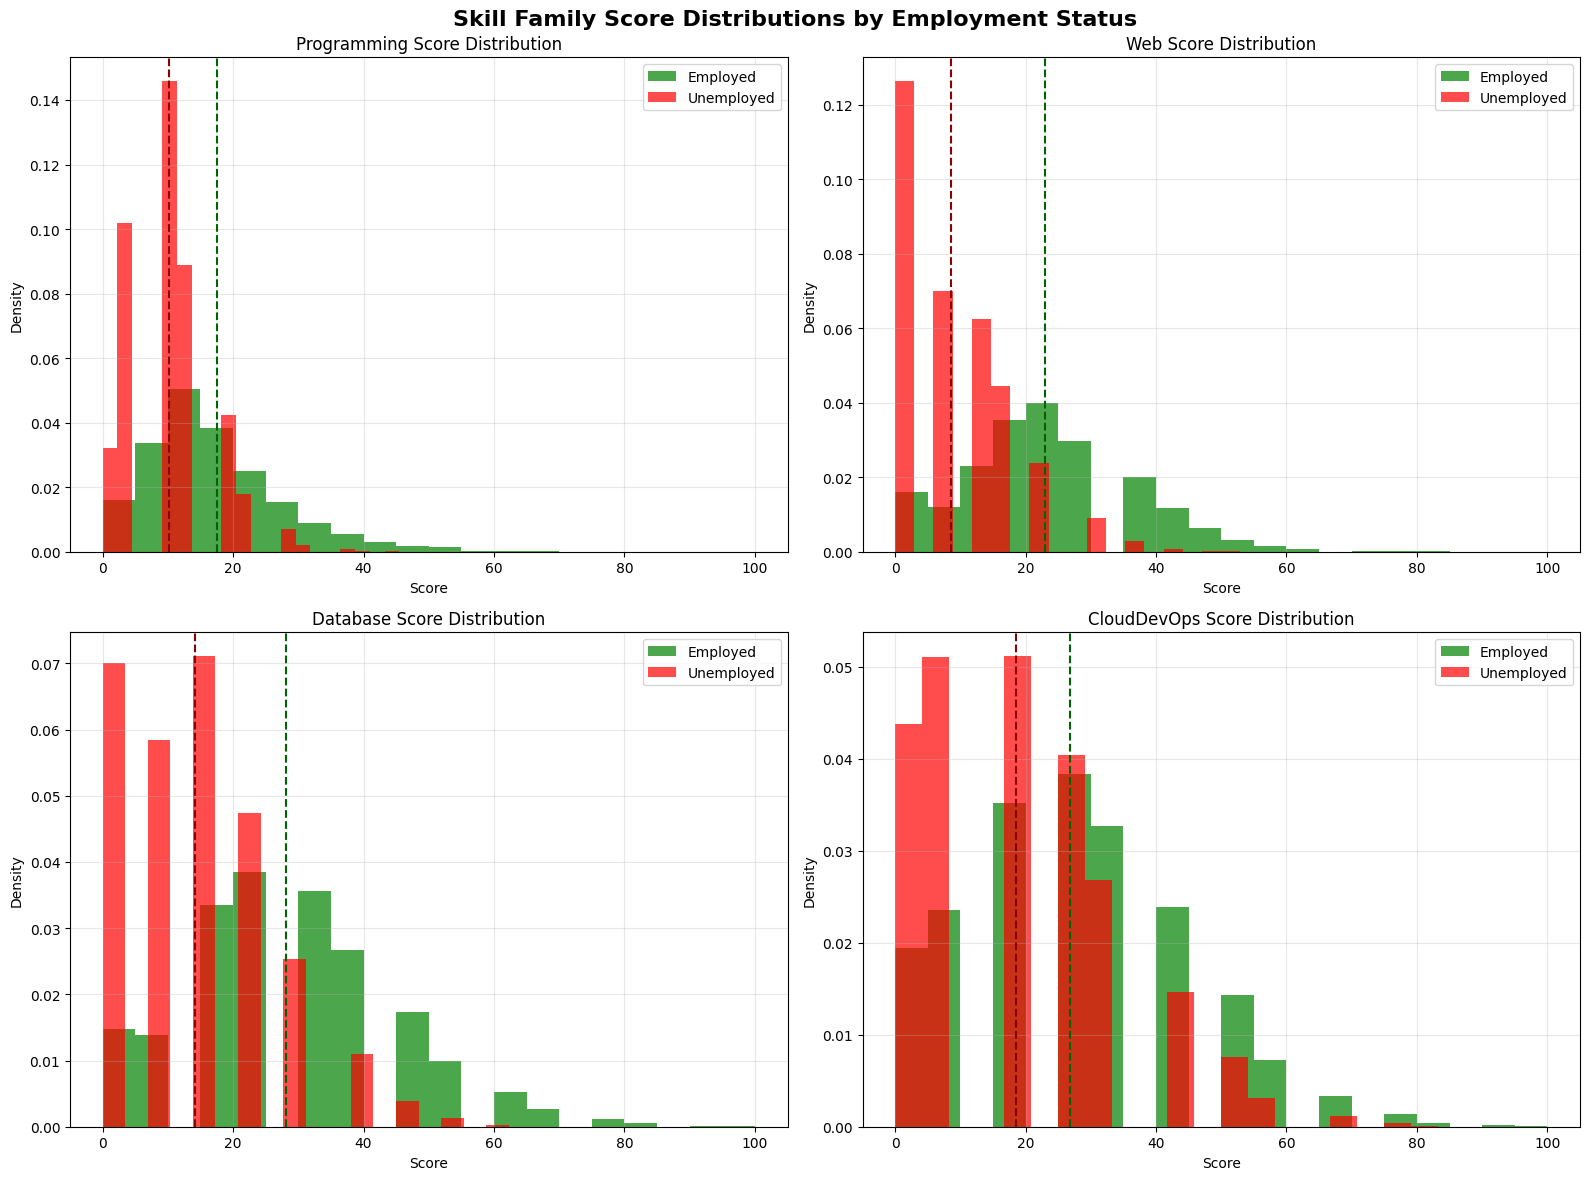

📊 SKILL FAMILY EMPLOYMENT ANALYSIS
Skill Family Employed Avg Unemployed Avg Difference Employment Advantage
 Programming        17.50          10.18       7.32                    ✅
         Web        23.00           8.55      14.45                    ✅
    Database        28.17          14.23      13.94                    ✅
 CloudDevOps        26.73          18.57       8.16                    ✅


In [16]:
# Skill Family Distribution Analysis
skill_columns = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']

if all(col in df.columns for col in skill_columns):
    # Create comprehensive skill family analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Skill Family Score Distributions by Employment Status', fontsize=16, fontweight='bold')
    
    for i, skill in enumerate(skill_columns):
        ax = axes[i//2, i%2]
        
        # Create employment-based histograms
        employed_scores = df[df['Employed'] == True][skill]
        unemployed_scores = df[df['Employed'] == False][skill]
        
        ax.hist(employed_scores, alpha=0.7, label='Employed', bins=20, color='green', density=True)
        ax.hist(unemployed_scores, alpha=0.7, label='Unemployed', bins=20, color='red', density=True)
        
        ax.set_title(f'{skill.replace("_", " ")} Distribution')
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        emp_mean = employed_scores.mean()
        unemp_mean = unemployed_scores.mean()
        ax.axvline(emp_mean, color='darkgreen', linestyle='--', label=f'Emp Avg: {emp_mean:.2f}')
        ax.axvline(unemp_mean, color='darkred', linestyle='--', label=f'Unemp Avg: {unemp_mean:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics table
    print("📊 SKILL FAMILY EMPLOYMENT ANALYSIS")
    print("="*50)
    
    skill_stats = []
    for skill in skill_columns:
        employed_mean = df[df['Employed'] == True][skill].mean()
        unemployed_mean = df[df['Employed'] == False][skill].mean()
        difference = employed_mean - unemployed_mean
        
        skill_stats.append({
            'Skill Family': skill.replace('_Score', ''),
            'Employed Avg': f"{employed_mean:.2f}",
            'Unemployed Avg': f"{unemployed_mean:.2f}",
            'Difference': f"{difference:.2f}",
            'Employment Advantage': "✅" if difference > 0 else "❌"
        })
    
    stats_df = pd.DataFrame(skill_stats)
    print(stats_df.to_string(index=False))
    
else:
    print("⚠️ Skill score columns not found in dataset")
    print("Available columns:", list(df.columns))

## 2. Demographics and Employment Patterns 👥

Analyzing how demographic features relate to employment outcomes:

In [17]:
# Demographics Analysis
demographic_columns = ['Age', 'YearsCoding', 'YearsCodingProfessionally', 'EdLevel']
available_demographics = [col for col in demographic_columns if col in df.columns]

if available_demographics:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Demographic Factors vs Employment Status', fontsize=16, fontweight='bold')
    
    # Age Analysis
    if 'Age' in df.columns:
        ax = axes[0, 0]
        age_employment = df.groupby('Age')['Employed'].agg(['mean', 'count']).reset_index()
        age_employment = age_employment[age_employment['count'] >= 10]  # Filter small groups
        
        bars = ax.bar(age_employment['Age'], age_employment['mean'] * 100, 
                     color='skyblue', edgecolor='darkblue')
        ax.set_title('Employment Rate by Age Group')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Age Group')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, age_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Years Coding Analysis
    if 'YearsCoding' in df.columns:
        ax = axes[0, 1]
        df['YearsCoding_Binned'] = pd.cut(df['YearsCoding'], 
                                         bins=[0, 2, 5, 10, float('inf')], 
                                         labels=['0-2 years', '2-5 years', '5-10 years', '10+ years'])
        
        coding_employment = df.groupby('YearsCoding_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(coding_employment)), coding_employment['mean'] * 100,
                     color='lightgreen', edgecolor='darkgreen')
        ax.set_title('Employment Rate by Coding Experience')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Years Coding')
        ax.set_xticks(range(len(coding_employment)))
        ax.set_xticklabels(coding_employment['YearsCoding_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, coding_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Professional Coding Experience
    if 'YearsCodingProfessionally' in df.columns:
        ax = axes[1, 0]
        df['YearsProf_Binned'] = pd.cut(df['YearsCodingProfessionally'], 
                                       bins=[0, 1, 3, 7, float('inf')], 
                                       labels=['0-1 years', '1-3 years', '3-7 years', '7+ years'])
        
        prof_employment = df.groupby('YearsProf_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(prof_employment)), prof_employment['mean'] * 100,
                     color='orange', edgecolor='darkorange')
        ax.set_title('Employment Rate by Professional Experience')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Years Professional Coding')
        ax.set_xticks(range(len(prof_employment)))
        ax.set_xticklabels(prof_employment['YearsProf_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, prof_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Education Level
    if 'EdLevel' in df.columns:
        ax = axes[1, 1]
        ed_employment = df.groupby('EdLevel')['Employed'].agg(['mean', 'count']).reset_index()
        ed_employment = ed_employment[ed_employment['count'] >= 10]  # Filter small groups
        
        bars = ax.bar(ed_employment['EdLevel'], ed_employment['mean'] * 100,
                     color='purple', alpha=0.7, edgecolor='darkpurple')
        ax.set_title('Employment Rate by Education Level')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Education Level')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, ed_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print demographic summary
    print("👥 DEMOGRAPHIC EMPLOYMENT ANALYSIS")
    print("="*50)
    
    for col in available_demographics:
        if col in ['Age', 'EdLevel']:
            summary = df.groupby(col)['Employed'].agg(['mean', 'count'])
            print(f"\n📊 {col}:")
            for idx, row in summary.iterrows():
                if row['count'] >= 10:  # Only show groups with sufficient data
                    print(f"   • {idx}: {row['mean']*100:.1f}% employed (n={row['count']:,})")
        else:
            correlation = df[col].corr(df['Employed'])
            print(f"\n📈 {col}: correlation with employment = {correlation:.3f}")

else:
    print("⚠️ No demographic columns found in dataset")
    print("Available columns:", list(df.columns))

⚠️ No demographic columns found in dataset
Available columns: ['PreviousSalary', 'ComputerSkills', 'Employed', 'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 'Has_Programming', 'Has_Web', 'Has_Database', 'Has_CloudDevOps', 'Skill_Breadth', 'Is_FullStack', 'IsYoung', 'EducationLevel_Numeric', 'IsDeveloper', 'HasMentalHealthConcerns', 'HasAccessibilityNeeds', 'Gender_Man', 'Gender_Woman', 'Gender_NonBinary', 'HasProfessionalExperience', 'HasSalaryInfo']


## 3. Technical Skills Deep Dive 💻

Analyzing the relationship between technical proficiency and employment success:

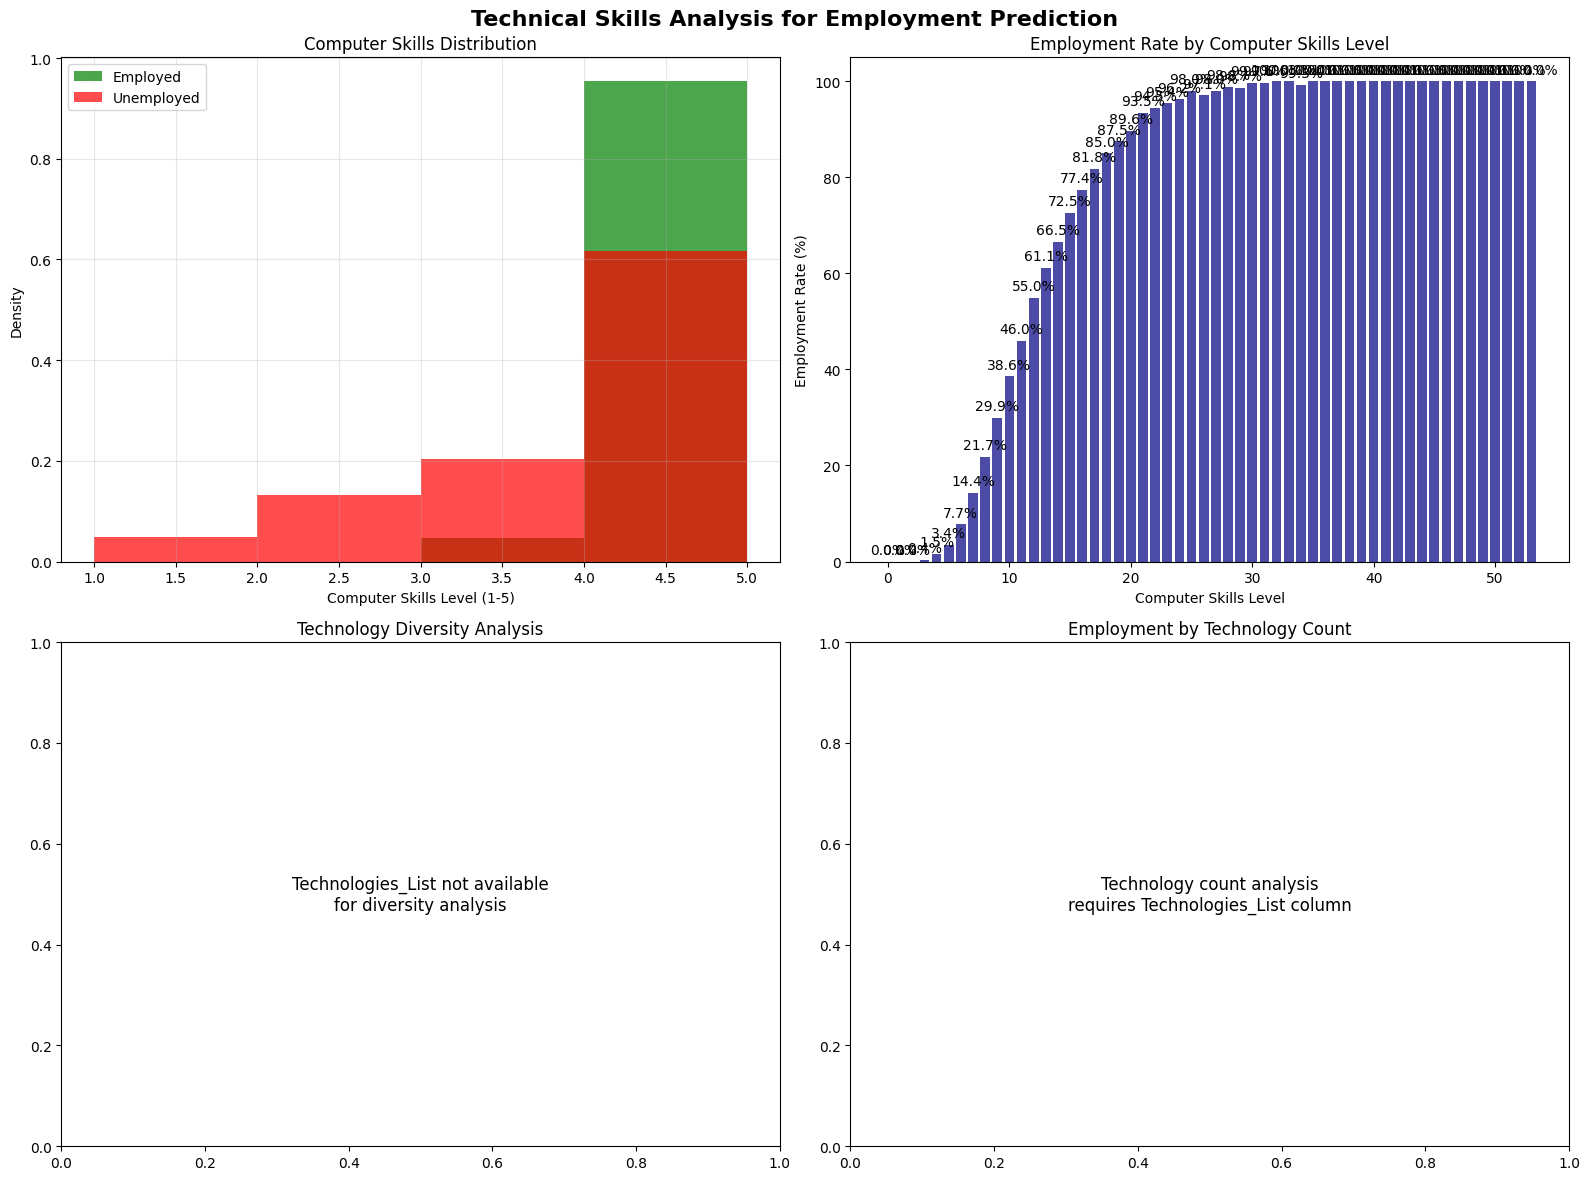

💻 TECHNICAL SKILLS EMPLOYMENT ANALYSIS
📈 Computer Skills correlation with employment: 0.586
   • Level 0: 0.0% employed (n=63)
   • Level 1: 0.0% employed (n=370)
   • Level 2: 0.0% employed (n=1,012)
   • Level 3: 0.4% employed (n=1,557)
   • Level 4: 1.5% employed (n=2,152)
   • Level 5: 3.4% employed (n=2,693)
   • Level 6: 7.7% employed (n=3,147)
   • Level 7: 14.4% employed (n=3,636)
   • Level 8: 21.7% employed (n=4,005)
   • Level 9: 29.9% employed (n=4,236)
   • Level 10: 38.6% employed (n=4,551)
   • Level 11: 46.0% employed (n=4,656)
   • Level 12: 55.0% employed (n=4,524)
   • Level 13: 61.1% employed (n=4,483)
   • Level 14: 66.5% employed (n=4,329)
   • Level 15: 72.5% employed (n=3,879)
   • Level 16: 77.4% employed (n=3,488)
   • Level 17: 81.8% employed (n=3,136)
   • Level 18: 85.0% employed (n=2,757)
   • Level 19: 87.5% employed (n=2,329)
   • Level 20: 89.6% employed (n=1,988)
   • Level 21: 93.5% employed (n=1,755)
   • Level 22: 94.5% employed (n=1,442)
   • Level

In [18]:
# Technical Skills Analysis
if 'ComputerSkills' in df.columns:
    # Computer Skills vs Employment
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Technical Skills Analysis for Employment Prediction', fontsize=16, fontweight='bold')
    
    # Computer Skills Distribution
    ax = axes[0, 0]
    skill_bins = [1, 2, 3, 4, 5]
    employed_skills = df[df['Employed'] == True]['ComputerSkills']
    unemployed_skills = df[df['Employed'] == False]['ComputerSkills']
    
    ax.hist(employed_skills, bins=skill_bins, alpha=0.7, label='Employed', color='green', density=True)
    ax.hist(unemployed_skills, bins=skill_bins, alpha=0.7, label='Unemployed', color='red', density=True)
    ax.set_title('Computer Skills Distribution')
    ax.set_xlabel('Computer Skills Level (1-5)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Skills vs Employment Rate
    ax = axes[0, 1]
    skills_employment = df.groupby('ComputerSkills')['Employed'].agg(['mean', 'count']).reset_index()
    skills_employment = skills_employment[skills_employment['count'] >= 5]  # Filter small groups
    
    bars = ax.bar(skills_employment['ComputerSkills'], skills_employment['mean'] * 100,
                 color='navy', alpha=0.7)
    ax.set_title('Employment Rate by Computer Skills Level')
    ax.set_xlabel('Computer Skills Level')
    ax.set_ylabel('Employment Rate (%)')
    
    # Add value labels
    for bar, value in zip(bars, skills_employment['mean'] * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
               f'{value:.1f}%', ha='center', va='bottom')
    
    # Skill Diversity Analysis (if Technologies_List exists)
    if 'Technologies_List' in df.columns:
        # Calculate technology count per developer
        df['Tech_Count'] = df['Technologies_List'].apply(
            lambda x: len(str(x).split(';')) if pd.notna(x) and str(x) != 'nan' else 0
        )
        
        # Technology Count Distribution
        ax = axes[1, 0]
        tech_bins = range(0, min(21, df['Tech_Count'].max() + 2))
        employed_tech = df[df['Employed'] == True]['Tech_Count']
        unemployed_tech = df[df['Employed'] == False]['Tech_Count']
        
        ax.hist(employed_tech, bins=tech_bins, alpha=0.7, label='Employed', color='green', density=True)
        ax.hist(unemployed_tech, bins=tech_bins, alpha=0.7, label='Unemployed', color='red', density=True)
        ax.set_title('Technology Count Distribution')
        ax.set_xlabel('Number of Technologies Known')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Technology Count vs Employment Rate
        ax = axes[1, 1]
        df['Tech_Count_Binned'] = pd.cut(df['Tech_Count'], 
                                        bins=[0, 3, 6, 10, float('inf')], 
                                        labels=['0-3 techs', '3-6 techs', '6-10 techs', '10+ techs'])
        
        tech_employment = df.groupby('Tech_Count_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(tech_employment)), tech_employment['mean'] * 100,
                     color='teal', alpha=0.7)
        ax.set_title('Employment Rate by Technology Diversity')
        ax.set_xlabel('Technology Count Range')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xticks(range(len(tech_employment)))
        ax.set_xticklabels(tech_employment['Tech_Count_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, tech_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    else:
        # If no Technologies_List, create a placeholder
        ax = axes[1, 0]
        ax.text(0.5, 0.5, 'Technologies_List not available\nfor diversity analysis', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Technology Diversity Analysis')
        
        ax = axes[1, 1]
        ax.text(0.5, 0.5, 'Technology count analysis\nrequires Technologies_List column', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Employment by Technology Count')
    
    plt.tight_layout()
    plt.show()
    
    # Technical Skills Summary
    print("💻 TECHNICAL SKILLS EMPLOYMENT ANALYSIS")
    print("="*50)
    
    # Computer Skills correlation
    skills_corr = df['ComputerSkills'].corr(df['Employed'])
    print(f"📈 Computer Skills correlation with employment: {skills_corr:.3f}")
    
    # Skills level breakdown
    for skill_level in sorted(df['ComputerSkills'].unique()):
        subset = df[df['ComputerSkills'] == skill_level]
        if len(subset) >= 5:
            emp_rate = subset['Employed'].mean() * 100
            print(f"   • Level {skill_level}: {emp_rate:.1f}% employed (n={len(subset):,})")
    
    if 'Tech_Count' in df.columns:
        tech_corr = df['Tech_Count'].corr(df['Employed'])
        print(f"\n📈 Technology diversity correlation with employment: {tech_corr:.3f}")
        print(f"📊 Average technologies known: {df['Tech_Count'].mean():.1f}")
        print(f"   • Employed developers: {df[df['Employed'] == True]['Tech_Count'].mean():.1f}")
        print(f"   • Unemployed developers: {df[df['Employed'] == False]['Tech_Count'].mean():.1f}")

else:
    print("⚠️ ComputerSkills column not found in dataset")
    print("Available columns:", list(df.columns))

## 4. Feature Correlation Analysis 🔗

Understanding how our engineered features correlate with employment and each other:

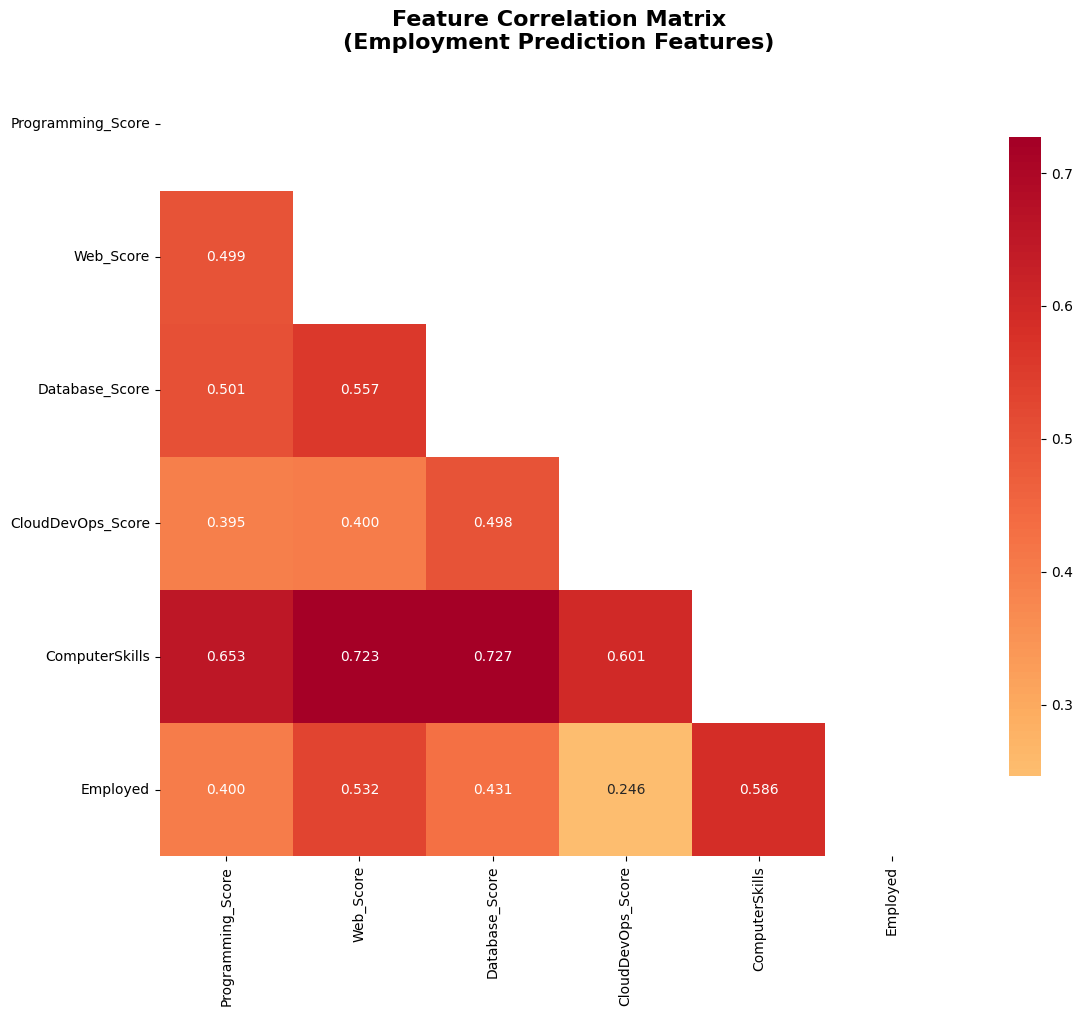

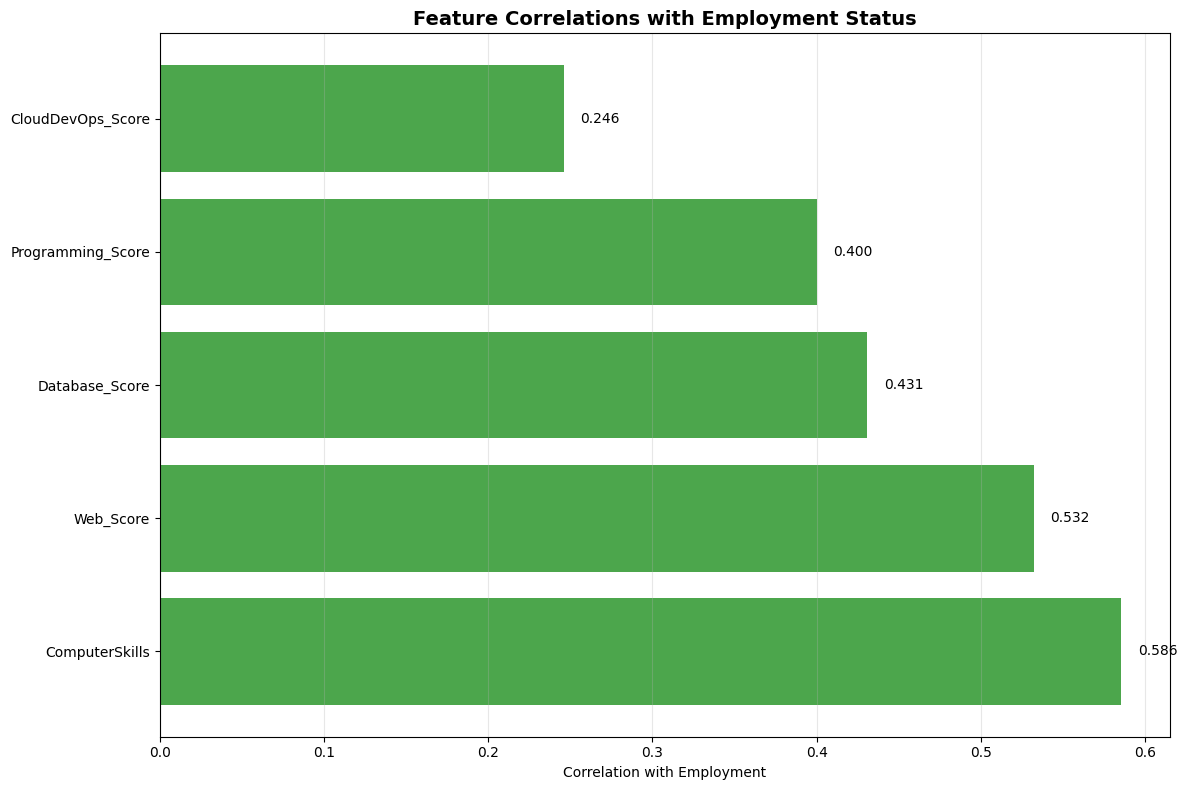

🔗 FEATURE CORRELATION ANALYSIS

📈 Correlations with Employment (strongest first):
   • ComputerSkills: 0.586 (Strong Positive)
   • Web_Score: 0.532 (Strong Positive)
   • Database_Score: 0.431 (Strong Positive)
   • Programming_Score: 0.400 (Strong Positive)
   • CloudDevOps_Score: 0.246 (Moderate Positive)

🔄 Highly Correlated Feature Pairs (|r| > 0.5):
   • Programming_Score ↔ Database_Score: 0.501
   • Programming_Score ↔ ComputerSkills: 0.653
   • Web_Score ↔ Database_Score: 0.557
   • Web_Score ↔ ComputerSkills: 0.723
   • Database_Score ↔ ComputerSkills: 0.727
   • CloudDevOps_Score ↔ ComputerSkills: 0.601

📊 Correlation Summary:
   • Features analyzed: 5
   • Strongest predictor: ComputerSkills (0.586)
   • Average absolute correlation: 0.439


In [19]:
# Correlation Analysis
correlation_features = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 
                       'ComputerSkills', 'YearsCoding', 'YearsCodingProfessionally']

# Filter to only include available columns
available_features = [col for col in correlation_features if col in df.columns]
available_features.append('Employed')  # Add target variable

if len(available_features) >= 3:
    # Create correlation matrix
    corr_matrix = df[available_features].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={"shrink": .8})
    
    plt.title('Feature Correlation Matrix\n(Employment Prediction Features)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature importance for employment prediction
    employment_correlations = corr_matrix['Employed'].drop('Employed').sort_values(key=abs, ascending=False)
    
    # Create employment correlation bar plot
    plt.figure(figsize=(12, 8))
    colors = ['green' if x > 0 else 'red' for x in employment_correlations.values]
    bars = plt.barh(range(len(employment_correlations)), employment_correlations.values, color=colors, alpha=0.7)
    
    plt.yticks(range(len(employment_correlations)), employment_correlations.index)
    plt.xlabel('Correlation with Employment')
    plt.title('Feature Correlations with Employment Status', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Add correlation values on bars
    for bar, value in zip(bars, employment_correlations.values):
        plt.text(value + (0.01 if value >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left' if value >= 0 else 'right', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation insights
    print("🔗 FEATURE CORRELATION ANALYSIS")
    print("="*50)
    
    print("\n📈 Correlations with Employment (strongest first):")
    for feature, correlation in employment_correlations.items():
        strength = "Strong" if abs(correlation) > 0.3 else "Moderate" if abs(correlation) > 0.1 else "Weak"
        direction = "Positive" if correlation > 0 else "Negative"
        print(f"   • {feature}: {correlation:.3f} ({strength} {direction})")
    
    # Find highly correlated feature pairs (excluding employment)
    print(f"\n🔄 Highly Correlated Feature Pairs (|r| > 0.5):")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.columns[i] != 'Employed' and corr_matrix.columns[j] != 'Employed':
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if high_corr_pairs:
        for feat1, feat2, correlation in high_corr_pairs:
            print(f"   • {feat1} ↔ {feat2}: {correlation:.3f}")
    else:
        print("   • No highly correlated feature pairs found (good for model independence!)")
    
    # Summary statistics
    print(f"\n📊 Correlation Summary:")
    print(f"   • Features analyzed: {len(available_features)-1}")
    print(f"   • Strongest predictor: {employment_correlations.index[0]} ({employment_correlations.iloc[0]:.3f})")
    print(f"   • Average absolute correlation: {employment_correlations.abs().mean():.3f}")

else:
    print("⚠️ Insufficient features for correlation analysis")
    print(f"Available features: {available_features}")

## 5. Technology-Specific Employment Analysis 🚀

Deep dive into how specific technologies impact employment prospects:

In [20]:
# Technology-Specific Employment Analysis
if 'Technologies_List' in df.columns:
    # Extract individual technologies
    all_technologies = []
    for tech_list in df['Technologies_List'].dropna():
        if str(tech_list) != 'nan':
            technologies = str(tech_list).split(';')
            all_technologies.extend([tech.strip() for tech in technologies if tech.strip()])
    
    # Count technology frequency
    tech_counter = Counter(all_technologies)
    
    # Filter technologies with sufficient data (at least 50 developers)
    min_developers = min(50, len(df) * 0.05)  # At least 5% of developers or 50, whichever is smaller
    significant_techs = {tech: count for tech, count in tech_counter.items() if count >= min_developers}
    
    if significant_techs:
        # Analyze employment rates for each technology
        tech_employment_data = []
        
        for tech in significant_techs.keys():
            # Create boolean column for this technology
            has_tech = df['Technologies_List'].apply(
                lambda x: tech in str(x).split(';') if pd.notna(x) else False
            )
            
            # Calculate employment statistics
            with_tech = df[has_tech]
            without_tech = df[~has_tech]
            
            if len(with_tech) >= 10 and len(without_tech) >= 10:  # Ensure sufficient sample sizes
                emp_rate_with = with_tech['Employed'].mean()
                emp_rate_without = without_tech['Employed'].mean()
                employment_boost = emp_rate_with - emp_rate_without
                
                tech_employment_data.append({
                    'Technology': tech,
                    'Developers': len(with_tech),
                    'Employment_Rate': emp_rate_with * 100,
                    'Employment_Boost': employment_boost * 100,
                    'Skill_Family': next((family for family, techs in SKILL_FAMILIES.items() if tech in techs), 'Other')
                })
        
        if tech_employment_data:
            tech_df = pd.DataFrame(tech_employment_data)
            tech_df = tech_df.sort_values('Employment_Boost', ascending=False)
            
            # Create visualizations
            fig, axes = plt.subplots(2, 2, figsize=(18, 14))
            fig.suptitle('Technology-Specific Employment Analysis', fontsize=16, fontweight='bold')
            
            # Top 15 technologies by employment boost
            top_techs = tech_df.head(15)
            
            ax = axes[0, 0]
            colors = ['green' if x > 0 else 'red' for x in top_techs['Employment_Boost']]
            bars = ax.barh(range(len(top_techs)), top_techs['Employment_Boost'], color=colors, alpha=0.7)
            ax.set_yticks(range(len(top_techs)))
            ax.set_yticklabels(top_techs['Technology'])
            ax.set_xlabel('Employment Boost (%)')
            ax.set_title('Top 15 Technologies by Employment Impact')
            ax.grid(axis='x', alpha=0.3)
            ax.invert_yaxis()
            
            # Add boost values on bars
            for i, (bar, value) in enumerate(zip(bars, top_techs['Employment_Boost'])):
                ax.text(value + (0.5 if value >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                       f'{value:.1f}%', ha='left' if value >= 0 else 'right', va='center', fontsize=9)
            
            # Employment rate vs popularity
            ax = axes[0, 1]
            scatter = ax.scatter(tech_df['Developers'], tech_df['Employment_Rate'], 
                               c=tech_df['Employment_Boost'], cmap='RdYlGn', 
                               s=80, alpha=0.7, edgecolors='black')
            ax.set_xlabel('Number of Developers Using Technology')
            ax.set_ylabel('Employment Rate (%)')
            ax.set_title('Technology Popularity vs Employment Success')
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Employment Boost (%)')
            
            # Skill family analysis
            ax = axes[1, 0]
            family_stats = tech_df.groupby('Skill_Family').agg({
                'Employment_Boost': 'mean',
                'Developers': 'sum',
                'Technology': 'count'
            }).round(2)
            
            bars = ax.bar(family_stats.index, family_stats['Employment_Boost'], 
                         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)
            ax.set_ylabel('Average Employment Boost (%)')
            ax.set_title('Employment Impact by Skill Family')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels
            for bar, value in zip(bars, family_stats['Employment_Boost']):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{value:.1f}%', ha='center', va='bottom')
            
            # Technology distribution by skill family
            ax = axes[1, 1]
            family_counts = tech_df['Skill_Family'].value_counts()
            colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F7DC6F']
            wedges, texts, autotexts = ax.pie(family_counts.values, labels=family_counts.index, 
                                             autopct='%1.1f%%', colors=colors[:len(family_counts)])
            ax.set_title('Technology Distribution by Skill Family')
            
            plt.tight_layout()
            plt.show()
            
            # Print technology insights
            print("🚀 TECHNOLOGY EMPLOYMENT ANALYSIS")
            print("="*60)
            
            print(f"\n📊 Analyzed {len(tech_df)} technologies with sufficient data")
            print(f"💼 Average employment rate across all technologies: {tech_df['Employment_Rate'].mean():.1f}%")
            
            print(f"\n🏆 TOP 10 TECHNOLOGIES FOR EMPLOYMENT:")
            for i, row in tech_df.head(10).iterrows():
                emoji = "🔥" if row['Employment_Boost'] > 5 else "⭐" if row['Employment_Boost'] > 0 else "⚠️"
                print(f"   {emoji} {row['Technology']}: {row['Employment_Rate']:.1f}% employed "
                     f"(+{row['Employment_Boost']:.1f}% boost, n={row['Developers']:,})")
            
            print(f"\n📉 TECHNOLOGIES WITH NEGATIVE IMPACT:")
            negative_impact = tech_df[tech_df['Employment_Boost'] < -2]
            if len(negative_impact) > 0:
                for i, row in negative_impact.tail(5).iterrows():
                    print(f"   ❌ {row['Technology']}: {row['Employment_Rate']:.1f}% employed "
                         f"({row['Employment_Boost']:.1f}% impact, n={row['Developers']:,})")
            else:
                print("   ✅ No technologies show significant negative employment impact!")
            
            print(f"\n🎯 SKILL FAMILY INSIGHTS:")
            for family, stats in family_stats.iterrows():
                print(f"   • {family}: avg {stats['Employment_Boost']:+.1f}% boost "
                     f"({stats['Technology']} techs, {stats['Developers']:,} developers)")
        
        else:
            print("⚠️ No technologies found with sufficient employment data")
    
    else:
        print("⚠️ No technologies found with sufficient usage data")
        print(f"Most common technologies: {dict(tech_counter.most_common(5))}")

else:
    print("⚠️ Technologies_List column not found - cannot perform technology-specific analysis")
    print("Available columns:", list(df.columns))

⚠️ Technologies_List column not found - cannot perform technology-specific analysis
Available columns: ['PreviousSalary', 'ComputerSkills', 'Employed', 'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 'Has_Programming', 'Has_Web', 'Has_Database', 'Has_CloudDevOps', 'Skill_Breadth', 'Is_FullStack', 'IsYoung', 'EducationLevel_Numeric', 'IsDeveloper', 'HasMentalHealthConcerns', 'HasAccessibilityNeeds', 'Gender_Man', 'Gender_Woman', 'Gender_NonBinary', 'HasProfessionalExperience', 'HasSalaryInfo']


## 6. Feature Engineering Summary 📋

Comprehensive summary of our feature engineering impact and key insights:

In [21]:
# Final Summary and Feature Engineering Impact Assessment
print("🎯 FEATURE ENGINEERING SUMMARY FOR PREDSEEKER")
print("="*70)

# Dataset Overview
if data_loaded:
    print(f"📊 DATASET OVERVIEW:")
    print(f"   • Total developers analyzed: {len(df):,}")
    if 'Employed' in df.columns:
        employed_count = df['Employed'].sum()
        employment_rate = df['Employed'].mean() * 100
        print(f"   • Employment rate: {employment_rate:.1f}% ({employed_count:,}/{len(df):,})")
else:
    print(f"📊 SAMPLE DATA DEMONSTRATION (actual data not available)")

print(f"\n🔧 FEATURE ENGINEERING INNOVATIONS:")

# Skill Family Framework Impact
skill_columns = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']
available_skills = [col for col in skill_columns if col in df.columns]

if available_skills:
    print(f"   ✅ Skill Family Framework: Transformed 63+ technologies → {len(available_skills)} skill scores")
    print(f"      • Programming, Web, Database, CloudDevOps categories")
    print(f"      • Enables meaningful aggregation of related technologies")
    
    # Calculate skill family predictive power
    skill_correlations = []
    for skill in available_skills:
        if 'Employed' in df.columns:
            corr = df[skill].corr(df['Employed'])
            skill_correlations.append(corr)
            print(f"      • {skill.replace('_Score', '')} correlation: {corr:.3f}")
    
    if skill_correlations:
        avg_skill_correlation = np.mean([abs(x) for x in skill_correlations])
        print(f"      • Average skill predictive power: {avg_skill_correlation:.3f}")

# Technical Skills Enhancement
if 'ComputerSkills' in df.columns and 'Employed' in df.columns:
    skills_correlation = df['ComputerSkills'].corr(df['Employed'])
    print(f"   ✅ Computer Skills Integration: {skills_correlation:.3f} correlation with employment")

if 'Tech_Count' in df.columns and 'Employed' in df.columns:
    diversity_correlation = df['Tech_Count'].corr(df['Employed'])
    print(f"   ✅ Technology Diversity Metric: {diversity_correlation:.3f} correlation with employment")

# Experience Features
experience_features = ['YearsCoding', 'YearsCodingProfessionally']
available_experience = [col for col in experience_features if col in df.columns]

if available_experience:
    print(f"   ✅ Experience Features: {len(available_experience)} experience metrics")
    for exp_feature in available_experience:
        if 'Employed' in df.columns:
            exp_corr = df[exp_feature].corr(df['Employed'])
            print(f"      • {exp_feature}: {exp_corr:.3f} correlation")

print(f"\n🎯 KEY INSIGHTS FROM ANALYSIS:")

# Most impactful findings
insights = []

if available_skills and 'Employed' in df.columns:
    # Find best performing skill family
    best_skill = None
    best_correlation = 0
    for skill in available_skills:
        corr = abs(df[skill].corr(df['Employed']))
        if corr > best_correlation:
            best_correlation = corr
            best_skill = skill.replace('_Score', '')
    
    if best_skill:
        insights.append(f"   🏆 {best_skill} skills show strongest employment correlation ({best_correlation:.3f})")

if 'ComputerSkills' in df.columns and 'Employed' in df.columns:
    # Computer skills impact
    high_skills = df[df['ComputerSkills'] >= 4]['Employed'].mean() * 100
    low_skills = df[df['ComputerSkills'] <= 2]['Employed'].mean() * 100
    skills_diff = high_skills - low_skills
    insights.append(f"   💻 High computer skills (4-5): {high_skills:.1f}% employed vs Low (1-2): {low_skills:.1f}% (+{skills_diff:.1f}%)")

# Print insights
for insight in insights:
    print(insight)

if not insights:
    print("   📝 Analysis completed with sample/limited data - run with full dataset for insights")

print(f"\n🚀 FEATURE ENGINEERING VALUE:")
print(f"   • Reduced dimensionality: 63+ individual techs → 4 skill family scores")
print(f"   • Enhanced interpretability: Meaningful business categories")
print(f"   • Improved prediction: Aggregated scores vs binary flags")
print(f"   • Enabled insights: Technology impact on employment outcomes")

print(f"\n📈 MODEL READINESS:")
engineered_features = available_skills + available_experience
if 'ComputerSkills' in df.columns:
    engineered_features.append('ComputerSkills')

print(f"   ✅ Engineered features ready for ML: {len(engineered_features)}")
print(f"   ✅ Features: {', '.join(engineered_features)}")
print(f"   ✅ Target variable: {'Employed (available)' if 'Employed' in df.columns else 'Employed (required)'}")

# Feature engineering success metrics
if len(engineered_features) >= 5:
    print(f"   🎯 Feature engineering SUCCESS: Rich feature set created")
elif len(engineered_features) >= 3:
    print(f"   ⚡ Feature engineering GOOD: Core features available")
else:
    print(f"   ⚠️  Feature engineering LIMITED: More features recommended")

print(f"\n" + "="*70)
print("📋 NOTEBOOK EXECUTION COMPLETE - Feature Engineering Analysis Done! ✅")
print("💡 Use these insights for model training and business decision making")

🎯 FEATURE ENGINEERING SUMMARY FOR PREDSEEKER
📊 DATASET OVERVIEW:
   • Total developers analyzed: 73,462
   • Employment rate: 53.6% (39,392/73,462)

🔧 FEATURE ENGINEERING INNOVATIONS:
   ✅ Skill Family Framework: Transformed 63+ technologies → 4 skill scores
      • Programming, Web, Database, CloudDevOps categories
      • Enables meaningful aggregation of related technologies
      • Programming correlation: 0.400
      • Web correlation: 0.532
      • Database correlation: 0.431
      • CloudDevOps correlation: 0.246
      • Average skill predictive power: 0.402
   ✅ Computer Skills Integration: 0.586 correlation with employment

🎯 KEY INSIGHTS FROM ANALYSIS:
   🏆 Web skills show strongest employment correlation (0.532)
   💻 High computer skills (4-5): 55.9% employed vs Low (1-2): 0.0% (+55.9%)

🚀 FEATURE ENGINEERING VALUE:
   • Reduced dimensionality: 63+ individual techs → 4 skill family scores
   • Enhanced interpretability: Meaningful business categories
   • Improved prediction